# Comparising images with and without overlapping objects within segmentation to evaluate ability for SAM2

In many Dutch residential areas, houses often have a small front gardens, resulting in façades that are frequently partially obscured by shrubs, trees, hedges, or other vegetation when viewed from the public street. This can affect the performance of computer vision models, particularly those tasked with façade segmentation or automated visual analysis of residential buildings. This can be the result of obscured architectural features, disrupted boundary detection, or irregular shapes that complicate segmentation tasks.
So first images are divided in two categories depending on the extent to which vegetation obscure the façade elements that are labeled (i.e. windows, doors and solar panels), and the impact on segmentation accuracy of SAM is measured, by comparing segmentation outputs.

## Imports

In [2]:
import os
import gc
import cv2
import csv

import json
import torch
import hydra
import shutil
import torchvision

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from PIL import Image, ImageDraw
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

In [6]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [7]:
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

PyTorch version: 2.7.1+cu118
Torchvision version: 0.22.1+cu118
CUDA is available: True
Using device: cuda


## Predefined variables

In [3]:
LABEL_DIR = "../images/Alles_JSONs"
ALLES_DIR = "../images/Alles"
ORIG_DIR = "../images/original"
OBSCURED_DIR = "../images/occluded"
VISIBLE_DIR = "../images/not_occluded"
OUTPUT_DIR = "../images/result_masks"
RESULTS_DIR = "../results"

LABEL_COLORS = {
    "Raam": [0.2, 0.6, 1.0],
    "Deur": [0.8, 0.2, 0.2],
    "Zonnepaneel": [1.0, 0.85, 0.0]
}

IMAGE_CONDITIONS = {
    "occluded": OBSCURED_DIR,
    "not_occluded": VISIBLE_DIR
}

os.makedirs(ORIG_DIR, exist_ok=True)
os.makedirs(OBSCURED_DIR, exist_ok=True)
os.makedirs(VISIBLE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LABEL_DIR, exist_ok=True)

# Model
SAM2_CHECKPOINT_PATH = "../sam2/checkpoints/sam2.1_hiera_small.pt"
SAM2_MODEL_CONFIG_PATH = "configs/sam2.1/sam2.1_hiera_s.yaml"

device = 'cuda:0'

In [33]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
hydra.initialize_config_module(config_module="sam2", version_base="1.2")

hydra.initialize_config_module()

## Copy the original images to the correct directories

The directory __"occluded"__ contains images of house façades that are occluded in such a way that:
- not all the corners of the labeled window(s), door or solar panel can not be "seen" or 
- the labeled object to segment is more than 50% covered.

The directory __"not_occluded"__ contains images of house façades that are NOT occluded in such a way that:
- all the corners of the labeled window(s), door or solar panel can not be "seen" AND 
- the labeled object to segment are less than 50% covered.

In [7]:
import os
import shutil

# List of files that have to be copied to the directory 'not_occluded':

not_occluded_files = [
    "image_103.jpg", "image_109.jpg", "image_110.jpg", "image_111.jpg",
    "image_112.jpg", "image_113.jpg", "image_114.jpg", "image_126.jpg",
    "image_13.jpg", "image_146.jpg", "image_148.jpg", "image_15.jpg",
    "image_151.jpg", "image_156.jpg", "image_160.jpg", "image_162.jpg",
    "image_171.jpg", "image_176.jpg", "image_177.jpg", "image_18.jpg",
    "image_185.jpg", "image_19.jpg", "image_193.jpg", "image_207.jpg",
    "image_208.jpg", "image_209.jpg", "image_210.jpg", "image_223.jpg",
    "image_224.jpg", "image_227.jpg", "image_23.jpg", "image_239.jpg",
    "image_24.jpg", "image_243.jpg", "image_25.jpg", "image_251.jpg",
    "image_254.jpg", "image_266.jpg", "image_267.jpg", "image_268.jpg",
    "image_275.jpg", "image_278.jpg", "image_279.jpg", "image_280.jpg",
    "image_281.jpg", "image_282.jpg", "image_283.jpg", "image_284.jpg",
    "image_285.jpg", "image_286.jpg", "image_287.jpg", "image_289.jpg",
    "image_292.jpg", "image_293.jpg", "image_294.jpg", "image_295.jpg",
    "image_297.jpg", "image_299.jpg", "image_306.jpg", "image_31.jpg",
    "image_311.jpg", "image_318.jpg", "image_319.jpg", "image_322.jpg",
    "image_327.jpg", "image_329.jpg", "image_33.jpg", "image_332.jpg",
    "image_334.jpg", "image_335.jpg", "image_337.jpg", "image_346.jpg",
    "image_349.jpg", "image_352.jpg", "image_356.jpg", "image_37.jpg",
    "image_372.jpg", "image_374.jpg", "image_376.jpg", "image_38.jpg",
    "image_385.jpg", "image_393.jpg", "image_395.jpg", "image_4.jpg",
    "image_401.jpg", "image_402.jpg", "image_404.jpg", "image_405.jpg",
    "image_408.jpg", "image_41.jpg", "image_415.jpg", "image_416.jpg",
    "image_417.jpg", "image_42.jpg", "image_424.jpg", "image_427.jpg",
    "image_428.jpg", "image_43.jpg", "image_432.jpg", "image_437.jpg",
    "image_443.jpg", "image_446.jpg", "image_447.jpg", "image_455.jpg",
    "image_46.jpg", "image_465.jpg", "image_467.jpg", "image_469.jpg",
    "image_470.jpg", "image_473.jpg", "image_477.jpg", "image_478.jpg",
    "image_48.jpg", "image_481.jpg", "image_484.jpg", "image_486.jpg",
    "image_487.jpg", "image_488.jpg", "image_489.jpg", "image_49.jpg",
    "image_495.jpg", "image_496.jpg", "image_52.jpg", "image_54.jpg",
    "image_59.jpg", "image_69.jpg", "image_7.jpg", "image_72.jpg",
    "image_73.jpg", "image_79.jpg", "image_8.jpg", "image_86.jpg",
    "image_87.jpg", "image_91.jpg", "image_93.jpg", "image_95.jpg",
    "image_97.jpg"
]

# Source and destiny directories
source_dir = ORIG_DIR
occluded_dir = OBSCURED_DIR
not_occluded_dir = VISIBLE_DIR

# Create directories if necessary
os.makedirs(occluded_dir, exist_ok=True)
os.makedirs(not_occluded_dir, exist_ok=True)

# Copy files to correct directory
for filename in os.listdir(source_dir):
    if filename in not_occluded_files:
        shutil.copy(os.path.join(source_dir, filename), not_occluded_dir)
    else:
        shutil.copy(os.path.join(source_dir, filename), occluded_dir)

print("Files are all copied to the correct directory.")

Files are all copied to the correct directory.


## SAM 2

### Build model

In [8]:
sam2 = build_sam2(SAM2_MODEL_CONFIG_PATH, SAM2_CHECKPOINT_PATH, device=device, apply_postprocessing=False)

mask_generator = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=16,
    points_per_batch=128,
    pred_iou_thresh=0.75,
    stability_score_thresh=0.9,
    stability_score_offset=0.7,
    # crop_n_layers=0,
    box_nms_thresh=0.5,
    # crop_n_points_downscale_factor=2,
    min_mask_region_area=250,
    # use_m2m=True
)

## Functions

### Get attributes from .JSON file like shapes, height and width

In [9]:
#################################################
#      Gets attributes from the annotation      #
#################################################

def get_attr_annotation(json_path):
    with open(json_path, "r") as f:
        annotation = json.load(f)

    height = data.get("imageHeight")
    width = data.get("imageWidth")
    
    shapes = []
    for shape in annotation["shapes"]:
        shapes.append(shape)

    return {**annotation, "shapes": shapes, "imageWidth": width, "imageHeight": height, "imageData": None}

## Transform the different forms to masks

In [10]:
def polygon_to_mask(points, img_h, img_w):
    if len(points) < 3:
        print(f"  WARNING: Polygon only has {len(points)} point(s), skipped.")
        return np.zeros((img_h, img_w), dtype=bool)
    
    mask = Image.new("L", (img_w, img_h), 0)
    ImageDraw.Draw(mask).polygon([(x, y) for x, y in points], outline=1, fill=1)
    return np.array(mask, dtype=bool)

In [11]:
def circle_to_mask(points, img_h, img_w):
    if len(points) < 2:
        print(f"  WARNING: Circle only has {len(points)} point(s), skipped.")
        return np.zeros((img_h, img_w), dtype=bool)
    
    cx, cy = points[0]
    rx, ry = points[1]
    radius = np.sqrt((rx-cx)**2 + (ry-cy)**2)

    mask = Image.new("L", (img_w, img_h), 0)
    ImageDraw.Draw(mask).ellipse([cx - radius, cy - radius, cx + radius, cy + radius], outline=1, fill=1)
    return np.array(mask, dtype=bool)

In [12]:
def rectangle_to_mask(points, img_h, img_w):
    if len(points) < 2:
        print(f"  WARNING: Rectangle only has {len(points)} point(s), skipped.")
        return np.zeros((img_h, img_w), dtype=bool)
    
    x1, y1 = points[0]
    x2, y2 = points[1]

    x_min, x_max = min(x1, x2), max(x1, x2)
    y_min, y_max = min(y1, y2), max(y1, y2)

    mask = Image.new("L", (img_w, img_h), 0)
    ImageDraw.Draw(mask).rectangle([x_min, y_min, x_max, y_max], outline=1, fill=1)
    return np.array(mask, dtype=bool)

In [13]:
def load_gt_masks(json_path, img_h, img_w):
    with open(json_path, "r") as f:
        data = json.load(f)

    masks = []
    for s in data["shapes"]:
        shape_type = s["shape_type"]
        points = s["points"]

        if shape_type == "polygon":
            mask = polygon_to_mask(points, img_h, img_w)
        elif shape_type == "circle":
            mask = circle_to_mask(points, img_h, img_w)
        elif shape_type == "rectangle":
            mask = rectangle_to_mask(points, img_h, img_w)
        else:
            print(f"  WARNING: Unsupported shape type '{shape_type}' in {json_path}, skipping.")
            continue

        if mask.sum() == 0:
            print(f"  WARNING: Generated empty mask for shape type '{shape_type}' in {json_path}, skipping.")
            continue

        masks.append({"label": s["label"], "mask": mask})

    return masks

In [14]:
# Calculates the overlap of the predicted segmentation and the ground truth, result will be between 0 and 1.
# No overlap being 0, total overlap being 1

def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0.0

In [15]:
def mask_overlaps_annotation(sam_mask, gt_masks, threshold=0.3):
    best_iou = 0.0
    best_label = None

    for gt in gt_masks:
        iou = compute_iou(sam_mask, gt["mask"])
        if iou > best_iou:
            best_iou = iou
            best_label = gt["label"]
    
    if best_iou >= threshold:
        return True, best_label, best_iou
    
    return False, None, 0.0

In [16]:
def filter_masks_by_annotation(sam_masks, gt_masks, iou_threshold=0.3):
    filtered_masks = []
    
    for sam in sam_masks:
        keep, label, iou = mask_overlaps_annotation(sam["segmentation"], gt_masks, threshold=iou_threshold)
        if keep:
            filtered_masks.append({**sam, "label": label, "annot_iou": iou})

    return filtered_masks

In [17]:
def match_and_score(ref_masks, cmp_masks):
    results = []
    for ref in ref_masks:
        best_iou = 0.0

        for cmp in cmp_masks:
            if cmp["label"] != ref["label"]:
                continue
            iou = compute_iou(ref["segmentation"], cmp["segmentation"])
            if iou > best_iou:
                best_iou = iou
        results.append({"label": ref["label"], "annot_iou": best_iou})
        
    return results

In [44]:
def save_masked_visualization(image_rgb, filtered_masks, gt_masks, filename, condition, output_dir=OUTPUT_DIR):
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    axes[0].imshow(image_rgb.astype(np.float32) / 255.0)
    gt_overlay = np.zeros((*image_rgb.shape[:2], 4), dtype=np.float32)
    for gt in gt_masks:
        color = LABEL_COLORS.get(gt["label"], [0.5, 0.5, 0.5])
        gt_overlay[gt["mask"]] = list(color) + [0.4]
    axes[0].imshow(gt_overlay)
    axes[0].set_title(f"{condition.capitalize()} - Ground Truth", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(image_rgb.astype(np.float32) / 255.0)
    sam_overlay = np.zeros((*image_rgb.shape[:2], 4), dtype=np.float32)
    for m in filtered_masks:
        color = LABEL_COLORS.get(m["label"], [0.5, 0.5, 0.5])
        sam_overlay[m["segmentation"]] = list(color) + [0.5]

        contours, _ = cv2.findContours(m["segmentation"].astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        cv2.drawContours(sam_overlay, contours, -1, list(color) + [1.0], thickness=1)

        ys, xs = np.where(m["segmentation"])
        if len(xs) > 0 and len(ys) > 0:
            center_x = int(xs.mean())
            center_y = int(ys.mean())
            axes[1].text(center_x, center_y, m["label"], color="white", fontsize=8, ha="center", va="center", bbox=dict(boxstyle="round,pad=0.1",facecolor='black', alpha=0.5, edgecolor='none'))

    axes[1].imshow(sam_overlay)
    axes[1].set_title(f"{condition.capitalize()} - {len(filtered_masks)} SAM Masks", fontsize=12)
    axes[1].axis("off")

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=LABEL_COLORS.get(label, [0.5, 0.5, 0.5])) for label in LABEL_COLORS
    ]
    axes[1].legend(legend_handles, LABEL_COLORS.keys(), loc="lower right", fontsize=8)

    save_path = os.path.join(output_dir, f"{os.path.splitext(filename)[0]}_{condition}.png")
    plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.close()
    print(f"  Visualization saved to {save_path}")

In [45]:
all_results = {}

for condition, img_dir in IMAGE_CONDITIONS.items():
    all_results[condition] = {}

## Run the model on the partly occluded images

In [51]:
##############################################################
#                                                            #
#   Filter all the images in the occluded dir and run model  #
#                                                            #
##############################################################
OCC_IMAGES = [f for f in os.listdir(OBSCURED_DIR) if f.endswith((".jpg", ".jpeg", ".png"))]

for file in sorted(OCC_IMAGES):
    json_occ = os.path.join(ORIG_DIR, os.path.splitext(file)[0] + ".json")
    if not os.path.exists(json_occ):
        print(f"\t  WARNING: No annotation found for {file} in occluded directory, skipping.")
        continue

    print(f"Processing {file}...")

    img_occ = Image.open(os.path.join(OBSCURED_DIR, file)).convert("RGB")
    occ_array = np.array(img_occ)
    img_h, img_w = occ_array.shape[:2]

    # Get the ground truth annotation
    gt_occ = load_gt_masks(json_occ, img_h, img_w)
    
    # Use model on array
    sam_occ = mask_generator.generate(occ_array)
    filtered_occ = filter_masks_by_annotation(sam_occ, gt_occ)
    all_results["occluded"][file] = [
        {"label": m["label"], "annot_iou": m["annot_iou"]} for m in filtered_occ
    ]
    save_masked_visualization(occ_array, filtered_occ, gt_occ, file, "occluded", OUTPUT_DIR)
    print(f"\t  Occluded: {len(filtered_occ)} SAM masks inside annotations.")

    # Free memory
    del sam_occ
    del filtered_occ
    del occ_array
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Processing image_10.jpg...
  Visualization saved to ../images/result_masks\image_10_occluded.png
	  Occluded: 3 SAM masks inside annotations.
Processing image_104.jpg...
  Visualization saved to ../images/result_masks\image_104_occluded.png
	  Occluded: 6 SAM masks inside annotations.
Processing image_105.jpg...
  Visualization saved to ../images/result_masks\image_105_occluded.png
	  Occluded: 3 SAM masks inside annotations.
Processing image_107.jpg...
  Visualization saved to ../images/result_masks\image_107_occluded.png
	  Occluded: 4 SAM masks inside annotations.
Processing image_123.jpg...
  Visualization saved to ../images/result_masks\image_123_occluded.png
	  Occluded: 7 SAM masks inside annotations.
Processing image_124.jpg...
  Visualization saved to ../images/result_masks\image_124_occluded.png
	  Occluded: 9 SAM masks inside annotations.
Processing image_129.jpg...
  Visualization saved to ../images/result_masks\image_129_occluded.png
	  Occluded: 5 SAM masks inside annotat

## Run the model on the not occluded images

In [53]:
##################################################################
#                                                                #
#   Filter all the images in the not occluded dir and run model  #
#                                                                #
##################################################################

VIS_IMAGES = [f for f in os.listdir(VISIBLE_DIR) if f.endswith((".jpg", ".jpeg", ".png"))]

for file in sorted(VIS_IMAGES):
    json_vis = os.path.join(VISIBLE_DIR, os.path.splitext(file)[0] + ".json")
    if not os.path.exists(json_vis):
        print(f"\t  WARNING: No annotation found for {file} in occluded directory, skipping.")
        continue

    print(f"Processing {file}...")

    img_vis = Image.open(os.path.join(VISIBLE_DIR, file)).convert("RGB")
    vis_array = np.array(img_vis)
    img_h, img_w = vis_array.shape[:2]

    gt_vis = load_gt_masks(json_vis, img_h, img_w)

    # Use model on array
    sam_vis = mask_generator.generate(vis_array)
    filtered_vis = filter_masks_by_annotation(sam_vis, gt_vis)
    all_results["not_occluded"][file] = [
        {"label": m["label"], "annot_iou": m["annot_iou"]} for m in filtered_vis
    ]
    save_masked_visualization(vis_array, filtered_vis, gt_vis, file, "not occluded", OUTPUT_DIR)
    print(f"\t  Not occluded: {len(filtered_vis)} SAM masks inside annotations.")


    # Free memory
    del sam_vis
    del filtered_vis
    del vis_array
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Processing image_103.jpg...
  Visualization saved to ../images/result_masks\image_103_not occluded.png
	  Not occluded: 14 SAM masks inside annotations.
Processing image_109.jpg...
  Visualization saved to ../images/result_masks\image_109_not occluded.png
	  Not occluded: 6 SAM masks inside annotations.
Processing image_110.jpg...
  Visualization saved to ../images/result_masks\image_110_not occluded.png
	  Not occluded: 14 SAM masks inside annotations.
Processing image_111.jpg...
  Visualization saved to ../images/result_masks\image_111_not occluded.png
	  Not occluded: 10 SAM masks inside annotations.
Processing image_112.jpg...
  Visualization saved to ../images/result_masks\image_112_not occluded.png
	  Not occluded: 5 SAM masks inside annotations.
Processing image_113.jpg...
  Visualization saved to ../images/result_masks\image_113_not occluded.png
	  Not occluded: 8 SAM masks inside annotations.
Processing image_114.jpg...
  Visualization saved to ../images/result_masks\image_114

## Compare the ground truth with the model

### Evaluation loop

In [56]:
with open(os.path.join(RESULTS_DIR, "sam2_results.csv"), "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["Condition", "File", "Label", "IoU"])
    for condition, files in all_results.items():
        for file, scores in files.items():
            for score in scores:
                writer.writerow([condition, file, score["label"], round(float(score["annot_iou"]), 4)])

print(f"Evaluation complete! Results saved to {RESULTS_DIR}/sam2_results.csv")

Evaluation complete! Results saved to ../results/sam2_results.csv


## Analysis

In [19]:
df = pd.read_csv(os.path.join(RESULTS_DIR, "sam2_results.csv"))

df["Label"] = df["Label"].str.lower()
df["Condition"] = df["Condition"].str.lower()

print(df.head())
print(f"\nAantal rijen: {len(df)}")
print(f"Condities: {df['Condition'].unique()}")
print(f"Labels: {df['Label'].unique()}")

  Condition           File        Label     IoU
0  occluded   image_10.jpg         raam  0.4493
1  occluded   image_10.jpg         raam  0.5807
2  occluded   image_10.jpg  zonnepaneel  0.8531
3  occluded  image_104.jpg         deur  0.5459
4  occluded  image_104.jpg         deur  0.3178

Aantal rijen: 2365
Condities: ['occluded' 'not_occluded']
Labels: ['raam' 'zonnepaneel' 'deur']


In [20]:
summary = df.groupby(["Condition", "Label"])["IoU"].agg(["mean", "std", "count"]).round(4)

print("Gemiddelde IoU per conditie per label:")
print(summary)

summary.to_csv(os.path.join(RESULTS_DIR, "iou_summary.csv"))

Gemiddelde IoU per conditie per label:
                            mean     std  count
Condition    Label                             
not_occluded deur         0.6637  0.1684    192
             raam         0.5772  0.1768    738
             zonnepaneel  0.6882  0.1636     36
occluded     deur         0.5664  0.1721    264
             raam         0.5310  0.1621   1066
             zonnepaneel  0.6910  0.1896     69


In [21]:
pivot = df.groupby(["Condition", "Label"])["IoU"].mean().unstack("Condition").round(4)
pivot = pivot[["occluded", "not_occluded"]]

print("Table for paper (mean IoU):")
print(pivot)

Table for paper (mean IoU):
Condition    occluded  not_occluded
Label                              
deur           0.5664        0.6637
raam           0.5310        0.5772
zonnepaneel    0.6910        0.6882


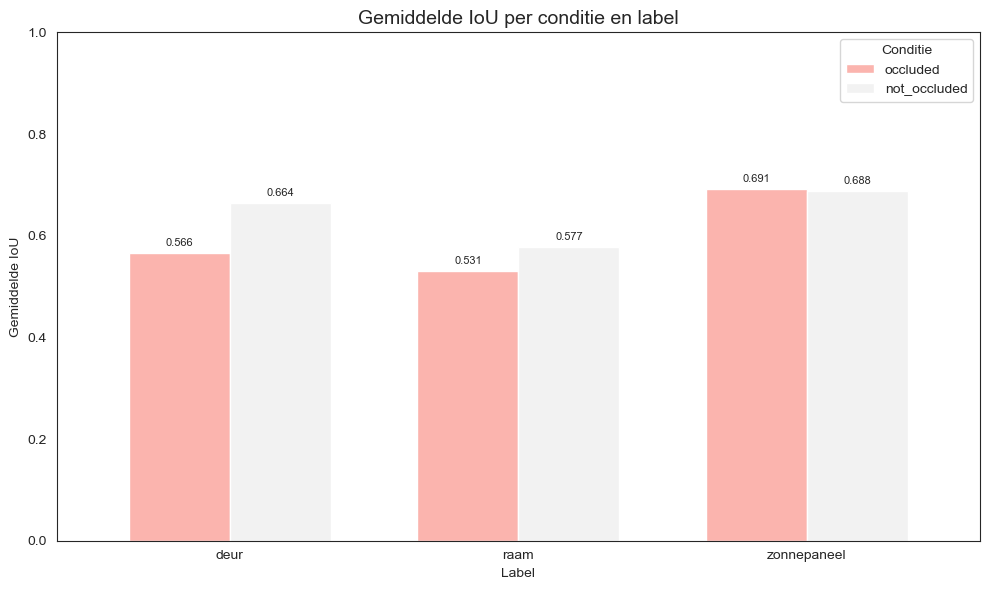

In [22]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind="bar", ax=ax, colormap="Pastel1", width=0.7)
ax.set_title("Gemiddelde IoU per conditie en label", fontsize=14)
ax.set_xlabel("Label")
ax.set_ylabel("Gemiddelde IoU")
ax.set_ylim(0, 1)
ax.legend(title="Conditie")
ax.tick_params(axis="x", rotation=0)
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.text(p.get_x() + p.get_width() / 2, height + 0.01, f"{height:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "iou_per_label.png"), dpi=150)
plt.show()

# Run statistical test in INTEGRATED notebook

In [23]:
print("Statistical tests (Wilcoxon signed-rank, original vs condition):")

for condition in ["occluded", "not_occluded"]:
    orig = df[df["Condition"] == "original"].set_index(["File", "Label"])["IoU"]
    cmp = df[df["Condition"] == condition].set_index(["File", "Label"])["IoU"]

    common = orig.index.intersection(cmp.index)
    if len(common) < 5:
        print(f"  Niet genoeg gemeenschappelijke samples voor {condition} (n={len(common)}), test overgeslagen.")
        continue

    stat, p = stats.wilcoxon(orig.loc[common].values, cmp.loc[common].values)
    sig = "significant" if p < 0.05 else "niet significant"
    print(f"  Original vs {condition.capitalize()}: p-value = {p:.5f} ({sig})")

Statistische tests (Wilcoxon signed-rank, original vs conditie):
  Niet genoeg gemeenschappelijke samples voor occluded (n=0), test overgeslagen.
  Niet genoeg gemeenschappelijke samples voor not_occluded (n=0), test overgeslagen.
